# Finalized Figures

Publication- and presentation-ready figures. Each figure is built up in
stages for slide animation.

In [14]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats as sp_stats

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

COLORS = {"normal": "black", "vse": "#4393c3"}
LABELS = {"normal": "Baseline", "vse": "Enhanced"}
REGION_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery", "IVS": "Myocardium", "Air": "Air"}
SLOPE_UP = "#2ca05a"
SLOPE_DOWN = "#d62728"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=6, zorder=5),
    boxprops=dict(linewidth=1.4, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.2, linestyle="-"),
    capprops=dict(linewidth=1.2),
    medianprops=dict(color="#2d2d2d", linewidth=1.8),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=6, alpha=0.7),
)

def color_boxes(bp, colors):
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

LEGEND_HANDLES = [
    Patch(facecolor="black", edgecolor="black", linewidth=1.4, label=LABELS["normal"]),
    Patch(facecolor="#4393c3", edgecolor="#4393c3", linewidth=1.4, label=LABELS["vse"]),
]

data = pd.read_csv(CSV_PATH)
data["snr"] = data["mean"] / data["std"]

SNR_OUTLIER_THRESHOLD = 100
data = data[data["snr"] <= SNR_OUTLIER_THRESHOLD].reset_index(drop=True)

print(f"{len(data)} rows  |  {data['patient'].nunique()} patients")

2354 rows  |  15 patients


In [15]:
regions = sorted(data["region"].unique())
cnr_regions = ["Ao", "PA"]

# SNR
snr_avg = (
    data.groupby(["patient", "region", "reconstruction"])["snr"]
    .mean().reset_index().rename(columns={"snr": "snr_mean"})
)

# CNR_myo
vessels = data[data["region"].isin(cnr_regions)].copy()
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "ivs_mean", "std": "ivs_std"})
cnr_myo_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_myo_data["cnr"] = (cnr_myo_data["mean"] - cnr_myo_data["ivs_mean"]) / cnr_myo_data["ivs_std"]

cnr_myo_avg = (
    cnr_myo_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_myo_pivot = cnr_myo_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_myo_pivot["vse_minus_normal"] = cnr_myo_pivot["vse"] - cnr_myo_pivot["normal"]
snr_pivot = snr_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="snr_mean")

# Time-averaged mean SI
si_avg = (
    data.groupby(["patient", "region", "reconstruction"])["mean"]
    .mean().reset_index().rename(columns={"mean": "si_mean"})
)
si_pivot = si_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="si_mean")
si_pivot["vse_minus_normal"] = si_pivot["vse"] - si_pivot["normal"]

# Stats
def _paired_wilcoxon(pivot_df, region):
    pdf = pivot_df.reset_index()
    sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
    _, p = sp_stats.wilcoxon(sub["vse"].values - sub["normal"].values)
    if p < 0.001: sig = "***"
    elif p < 0.01: sig = "**"
    elif p < 0.05: sig = "*"
    else: sig = "ns"
    return p, sig

sig_cache = {}
for region in cnr_regions:
    sig_cache[("CNR_myo", region)] = _paired_wilcoxon(cnr_myo_pivot, region)
    sig_cache[("SNR", region)] = _paired_wilcoxon(snr_pivot, region)

for k, (p, s) in sig_cache.items():
    print(f"{k[0]:>8s} {k[1]}: p={p:.4f} ({s})")

 CNR_myo Ao: p=0.0003 (***)
     SNR Ao: p=0.4543 (ns)
 CNR_myo PA: p=0.0004 (***)
     SNR PA: p=0.0580 (ns)


## Figure 1: CNR$_{myo}$ — Baseline vs Enhanced

Four build-up stages for slide animation:
1. Empty axes (labels, grid, no data)
2. Baseline only
3. Baseline + Enhanced
4. Full figure with significance brackets

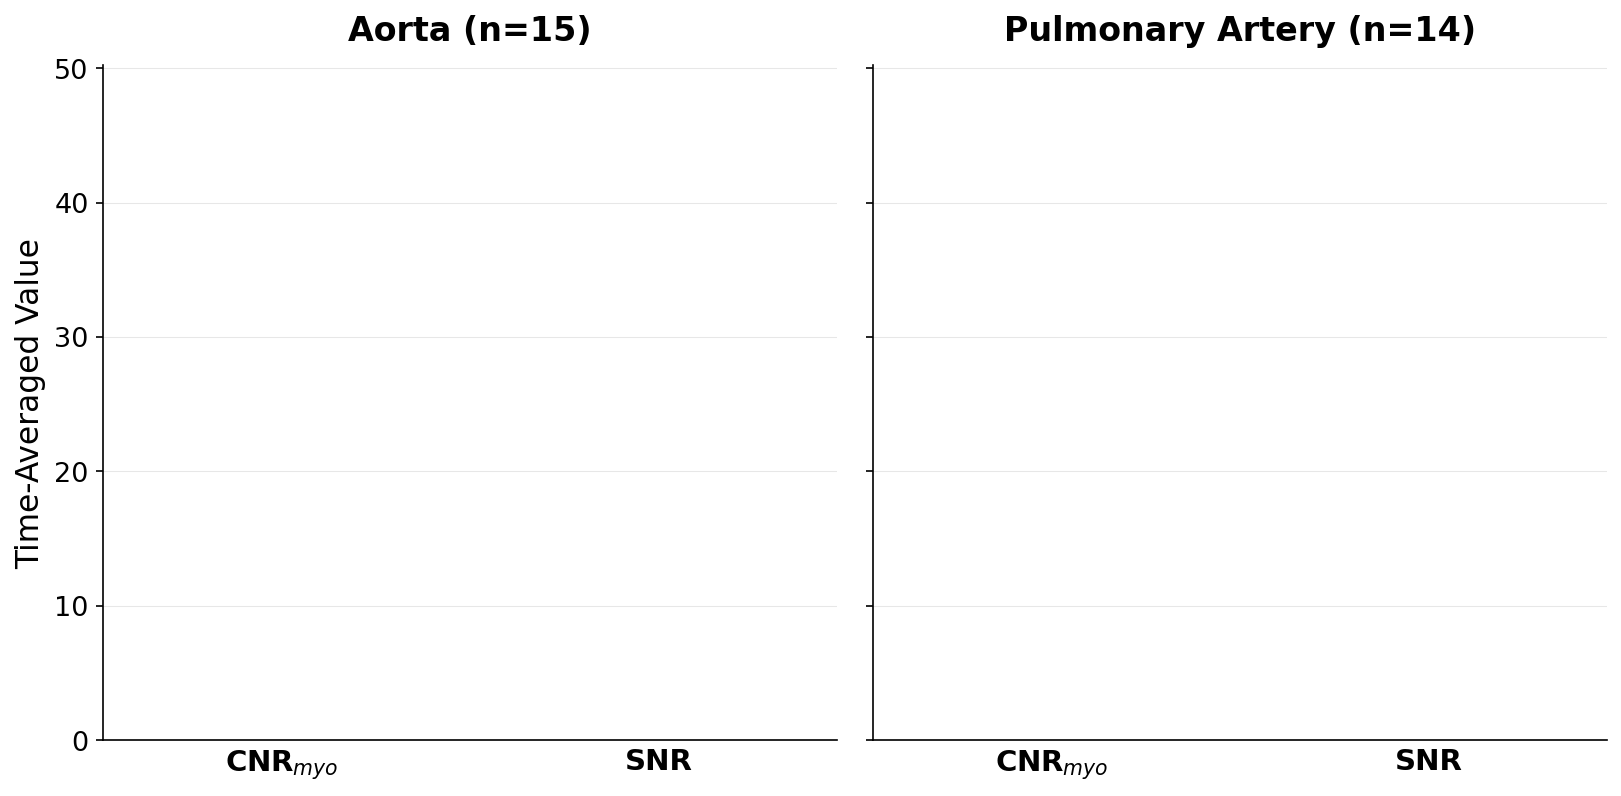

Saved: fig1_cnr_myo_empty.png


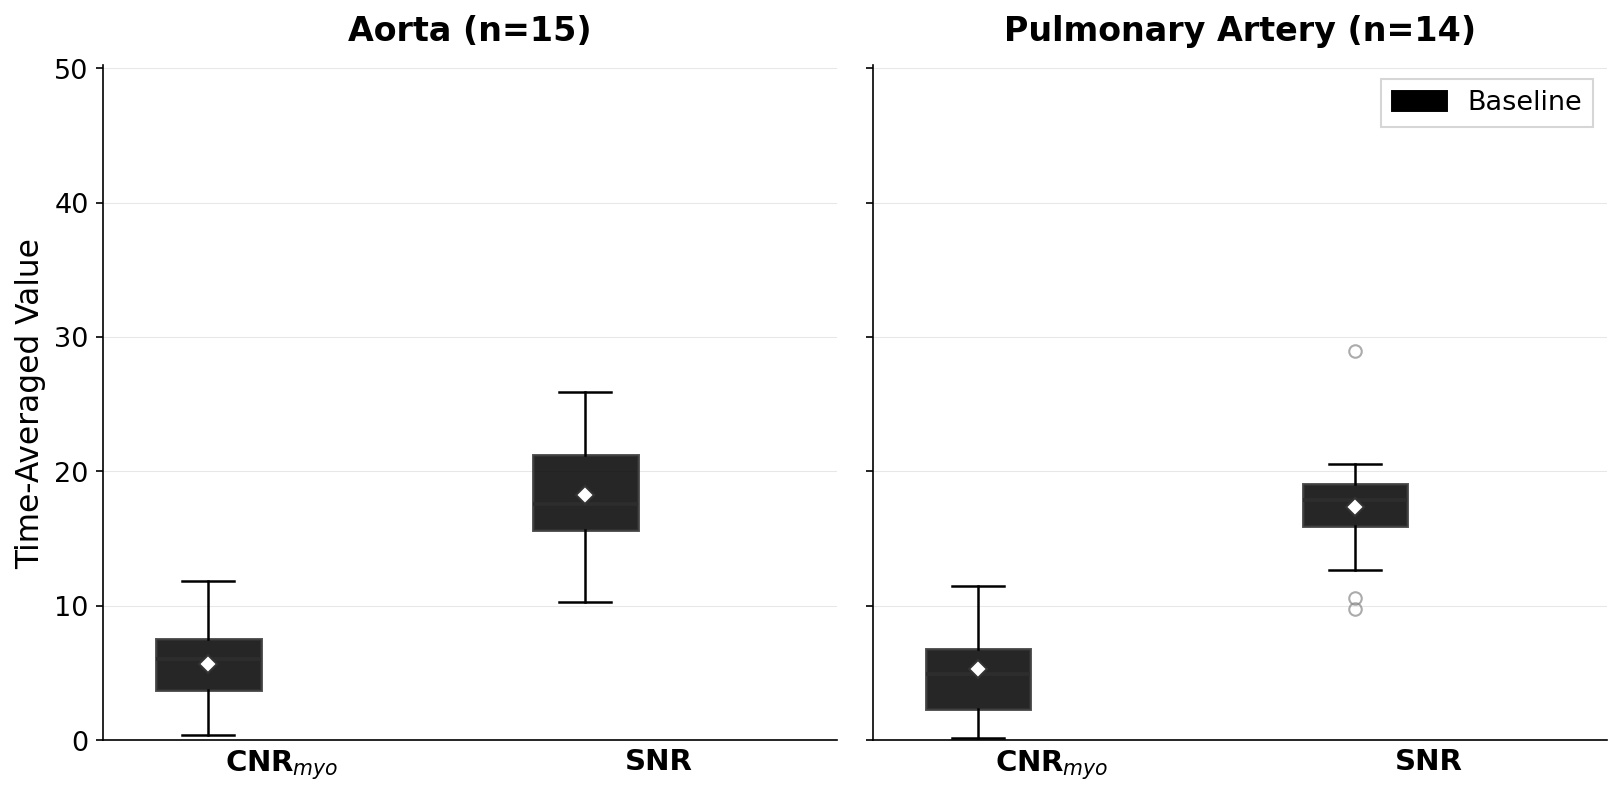

Saved: fig1_cnr_myo_baseline.png


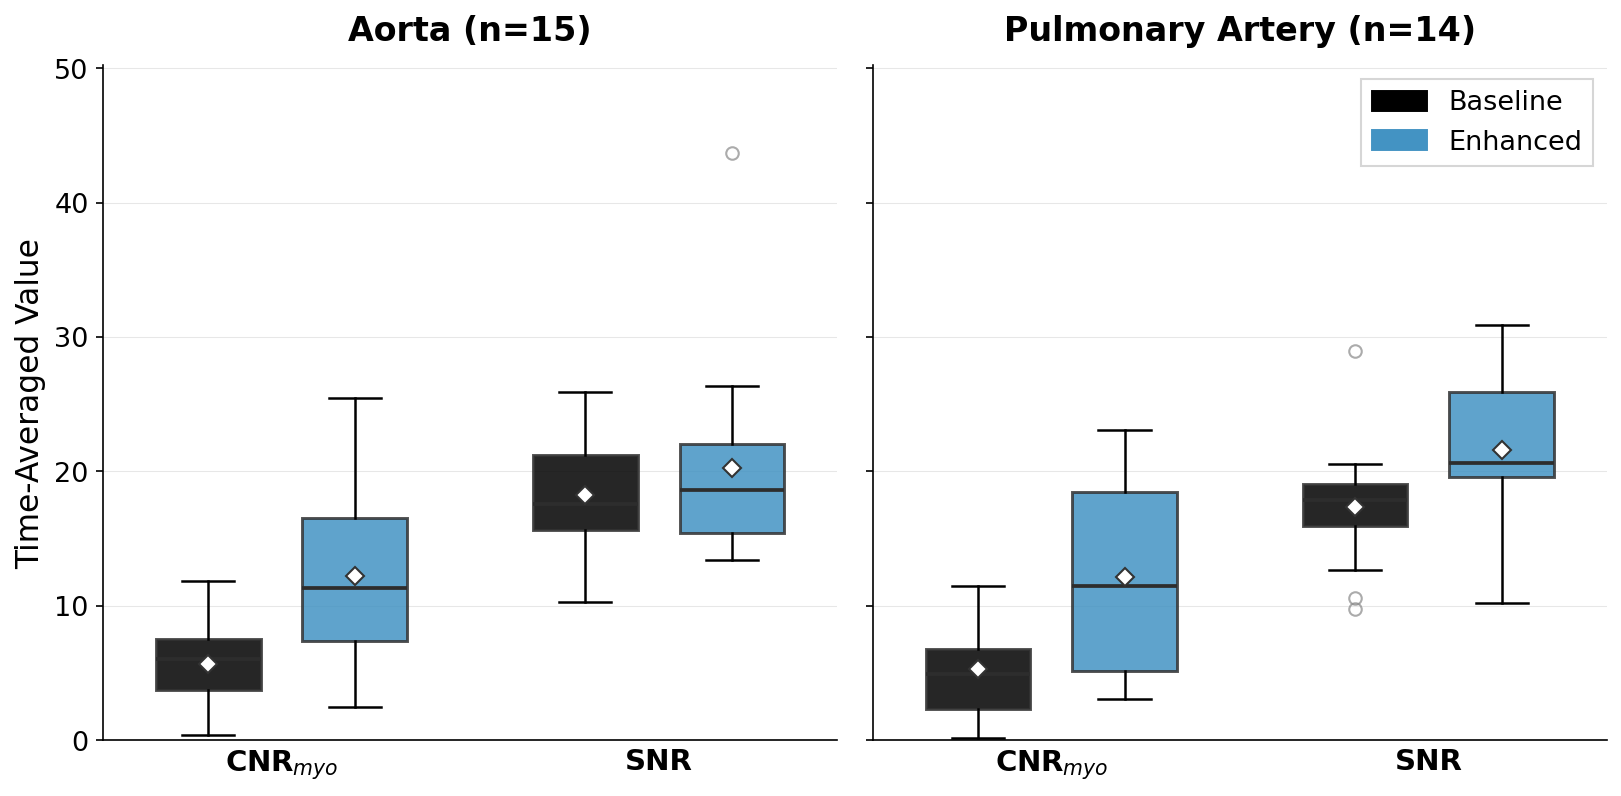

Saved: fig1_cnr_myo_both.png


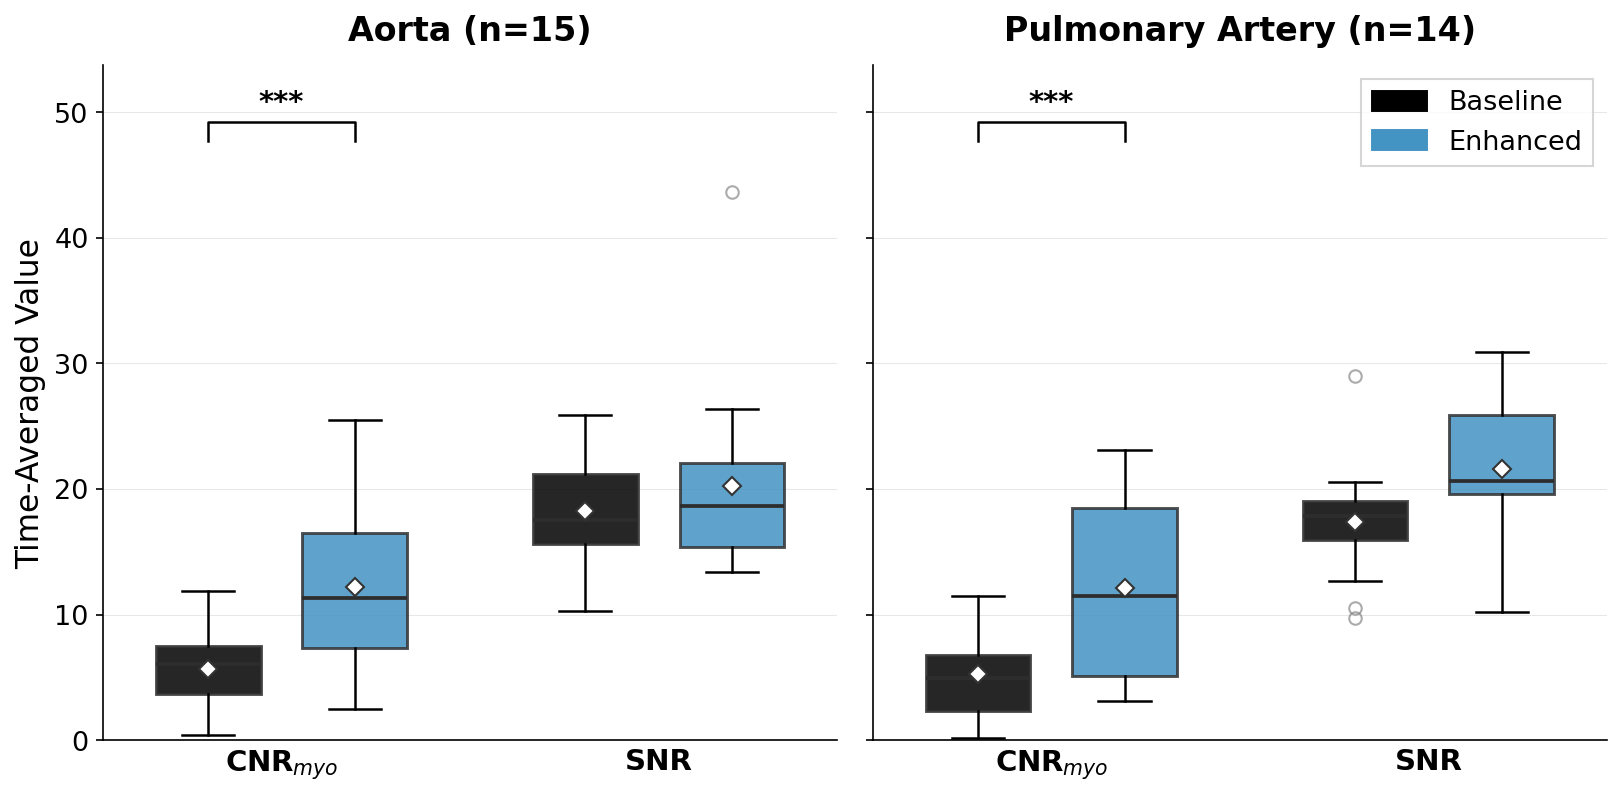

Saved: fig1_cnr_myo_full.png


In [16]:
def _get_nv(df, region, col):
    sub = df[df["region"] == region]
    return (sub[sub["reconstruction"] == "normal"][col],
            sub[sub["reconstruction"] == "vse"][col])

def _annotate_sig(ax, sig, x0, x1):
    if sig == "ns":
        return
    ylim = ax.get_ylim()
    y = ylim[1] - (ylim[1] - ylim[0]) * 0.02
    h = (ylim[1] - ylim[0]) * 0.03
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color="black", linewidth=1.2)
    ax.text((x0 + x1) / 2, y + h * 0.3, sig, ha="center", va="bottom",
            fontsize=14, fontweight="bold")
    ax.set_ylim(ylim[0], y + h * 3)

# Precompute consistent y-limit across all data
all_vals = []
for region in cnr_regions:
    cn, cv = _get_nv(cnr_myo_avg, region, "cnr_mean")
    sn, sv = _get_nv(snr_avg, region, "snr_mean")
    all_vals.extend([cn, cv, sn, sv])
global_max = max(v.max() for v in all_vals)
YLIM = (0, global_max * 1.15)

STAGES = [
    ("empty",    False, False, False),
    ("baseline", True,  False, False),
    ("both",     True,  True,  False),
    ("full",     True,  True,  True),
]

for stage_name, show_baseline, show_enhanced, show_sig in STAGES:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5.5),
                             sharey=True)

    for ax, region in zip(axes, cnr_regions):
        cnr_n, cnr_v = _get_nv(cnr_myo_avg, region, "cnr_mean")
        snr_n, snr_v = _get_nv(snr_avg, region, "snr_mean")

        box_data = []
        box_positions = []
        box_colors = []

        if show_baseline:
            box_data.extend([cnr_n, snr_n])
            box_positions.extend([0, 1.8])
            box_colors.extend([COLORS["normal"], COLORS["normal"]])

        if show_enhanced:
            box_data.extend([cnr_v, snr_v])
            box_positions.extend([0.7, 2.5])
            box_colors.extend([COLORS["vse"], COLORS["vse"]])

        if box_data:
            bp = ax.boxplot(box_data, positions=box_positions, widths=0.5, **BOXPLOT_KW)
            color_boxes(bp, box_colors)

        ax.set_xlim(-0.5, 3.0)
        ax.set_xticks([0.35, 2.15])
        ax.set_xticklabels(["CNR$_{myo}$", "SNR"], fontweight="bold", fontsize=14)
        n_region = len(cnr_n)
        ax.set_title(f"{REGION_LABELS[region]} (n={n_region})", fontweight="bold",
                     fontsize=16, pad=12)
        ax.tick_params(axis="x", length=0)
        ax.tick_params(axis="y", labelsize=13)
        ax.set_ylim(YLIM)

        if show_sig:
            _, sig_cnr = sig_cache[("CNR_myo", region)]
            _annotate_sig(ax, sig_cnr, x0=0, x1=0.7)
            _, sig_snr = sig_cache[("SNR", region)]
            _annotate_sig(ax, sig_snr, x0=1.8, x1=2.5)

    axes[0].set_ylabel("Time-Averaged Value", fontsize=15)

    legend_handles = []
    if show_baseline:
        legend_handles.append(LEGEND_HANDLES[0])
    if show_enhanced:
        legend_handles.append(LEGEND_HANDLES[1])
    if legend_handles:
        axes[-1].legend(handles=legend_handles, loc="upper right", ncol=1,
                        frameon=True, fancybox=False, edgecolor="#ccc",
                        fontsize=13)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig1_cnr_myo_{stage_name}.png",
                bbox_inches="tight", dpi=300, facecolor="white")
    plt.show()
    print(f"Saved: fig1_cnr_myo_{stage_name}.png")

 CNR_myo Ao: p=0.000000 (***)
     SNR Ao: p=0.008945 (**)
 CNR_myo PA: p=0.000000 (***)
     SNR PA: p=0.000002 (***)


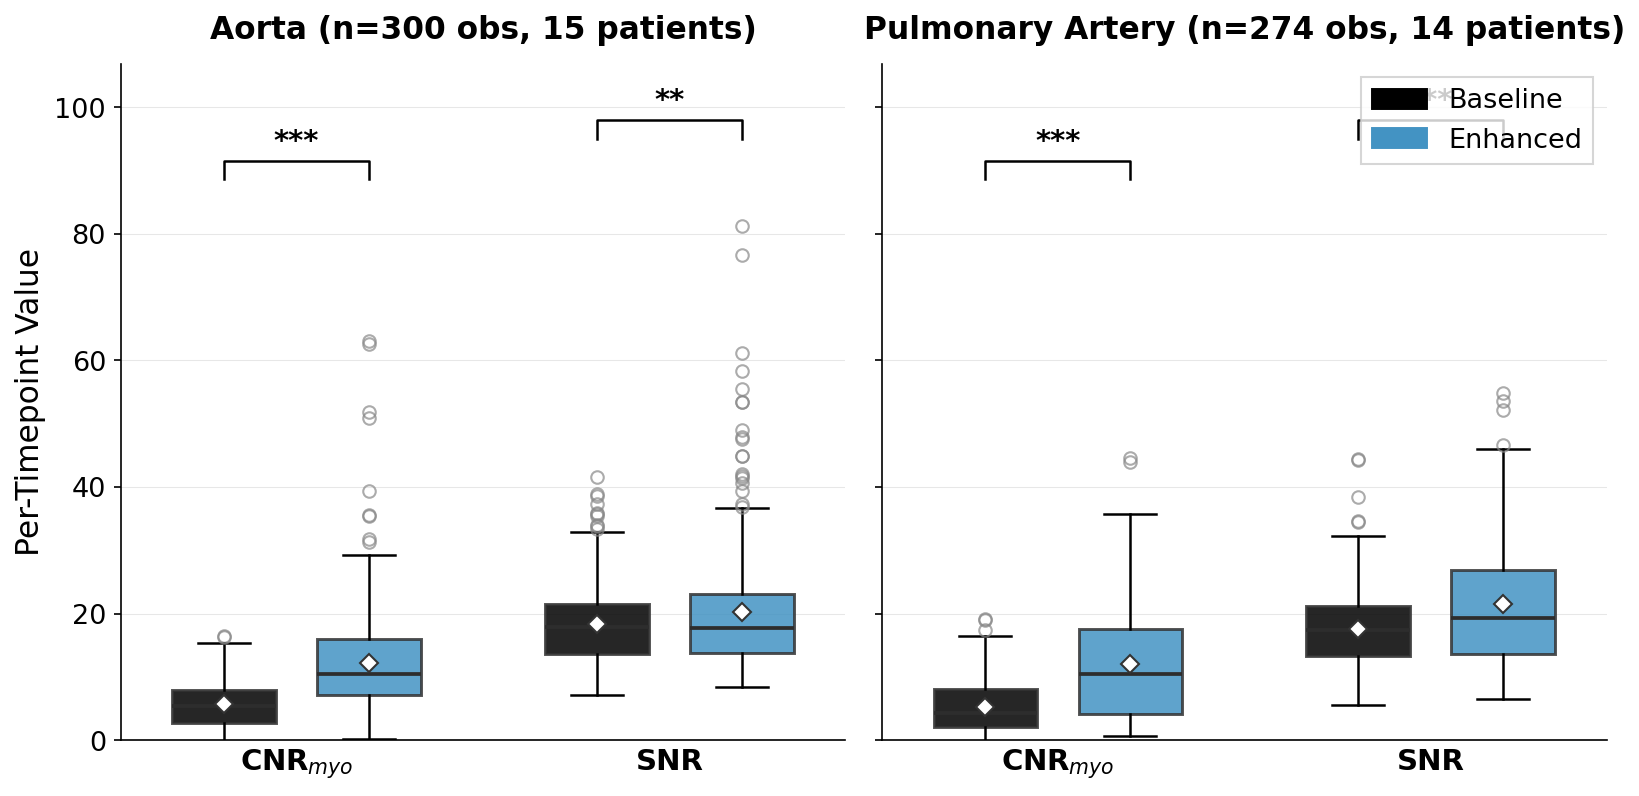

Saved: fig1_cnr_myo_per_timepoint.png


In [17]:
# Figure 1 variant: per-timepoint (no averaging across cardiac phases)
# Each (patient, timepoint) pair is a separate observation.

# Per-timepoint SNR pivot: paired by (patient, region, timepoint)
snr_tp = data[data["region"].isin(cnr_regions)][["patient", "region", "reconstruction", "timepoint", "snr"]]
snr_tp_pivot = snr_tp.pivot_table(index=["patient", "region", "timepoint"],
                                  columns="reconstruction", values="snr")
snr_tp_pivot = snr_tp_pivot.dropna(subset=["normal", "vse"])

# cnr_myo_data already has per-timepoint CNR
cnr_tp_pivot = cnr_myo_data.pivot_table(index=["patient", "region", "timepoint"],
                                        columns="reconstruction", values="cnr")
cnr_tp_pivot = cnr_tp_pivot.dropna(subset=["normal", "vse"])

# Paired Wilcoxon on per-timepoint differences
tp_sig_cache = {}
for region in cnr_regions:
    sub_cnr = cnr_tp_pivot.loc[cnr_tp_pivot.index.get_level_values("region") == region]
    _, p_cnr = sp_stats.wilcoxon(sub_cnr["vse"].values - sub_cnr["normal"].values)
    tp_sig_cache[("CNR_myo", region)] = (p_cnr,
        "***" if p_cnr < 0.001 else "**" if p_cnr < 0.01 else "*" if p_cnr < 0.05 else "ns")

    sub_snr = snr_tp_pivot.loc[snr_tp_pivot.index.get_level_values("region") == region]
    _, p_snr = sp_stats.wilcoxon(sub_snr["vse"].values - sub_snr["normal"].values)
    tp_sig_cache[("SNR", region)] = (p_snr,
        "***" if p_snr < 0.001 else "**" if p_snr < 0.01 else "*" if p_snr < 0.05 else "ns")

for k, (p, s) in tp_sig_cache.items():
    print(f"{k[0]:>8s} {k[1]}: p={p:.6f} ({s})")

def _get_nv_tp(pivot, region):
    sub = pivot.loc[pivot.index.get_level_values("region") == region]
    return sub["normal"], sub["vse"]

# Consistent y-limit
tp_all = []
for region in cnr_regions:
    cn, cv = _get_nv_tp(cnr_tp_pivot, region)
    sn, sv = _get_nv_tp(snr_tp_pivot, region)
    tp_all.extend([cn, cv, sn, sv])
TP_YLIM = (0, max(v.max() for v in tp_all) * 1.15)

fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5.5),
                         sharey=True)

for ax, region in zip(axes, cnr_regions):
    cnr_n, cnr_v = _get_nv_tp(cnr_tp_pivot, region)
    snr_n, snr_v = _get_nv_tp(snr_tp_pivot, region)

    bp = ax.boxplot(
        [cnr_n, cnr_v, snr_n, snr_v],
        positions=[0, 0.7, 1.8, 2.5],
        widths=0.5,
        **BOXPLOT_KW,
    )
    color_boxes(bp, [COLORS["normal"], COLORS["vse"]] * 2)

    ax.set_xlim(-0.5, 3.0)
    ax.set_xticks([0.35, 2.15])
    ax.set_xticklabels(["CNR$_{myo}$", "SNR"], fontweight="bold", fontsize=14)
    n_obs = len(cnr_n)
    n_pat = cnr_tp_pivot.loc[cnr_tp_pivot.index.get_level_values("region") == region].index.get_level_values("patient").nunique()
    ax.set_title(f"{REGION_LABELS[region]} (n={n_obs} obs, {n_pat} patients)",
                 fontweight="bold", fontsize=15, pad=12)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_ylim(TP_YLIM)

    _, sig_cnr = tp_sig_cache[("CNR_myo", region)]
    _annotate_sig(ax, sig_cnr, x0=0, x1=0.7)
    _, sig_snr = tp_sig_cache[("SNR", region)]
    _annotate_sig(ax, sig_snr, x0=1.8, x1=2.5)

axes[0].set_ylabel("Per-Timepoint Value", fontsize=15)
axes[-1].legend(handles=LEGEND_HANDLES, loc="upper right", ncol=1,
                frameon=True, fancybox=False, edgecolor="#ccc", fontsize=13)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_cnr_myo_per_timepoint.png",
            bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
print(f"Saved: fig1_cnr_myo_per_timepoint.png")

## Figure 2: Per-Patient CNR$_{myo}$ — Baseline → Enhanced

Paired slope graph. Each line connects one patient's time-averaged CNR under
Baseline (left) to Enhanced (right). Green = improved; red = decreased.

Build-up stages:
1. Baseline points only
2. Full figure with lines to Enhanced points

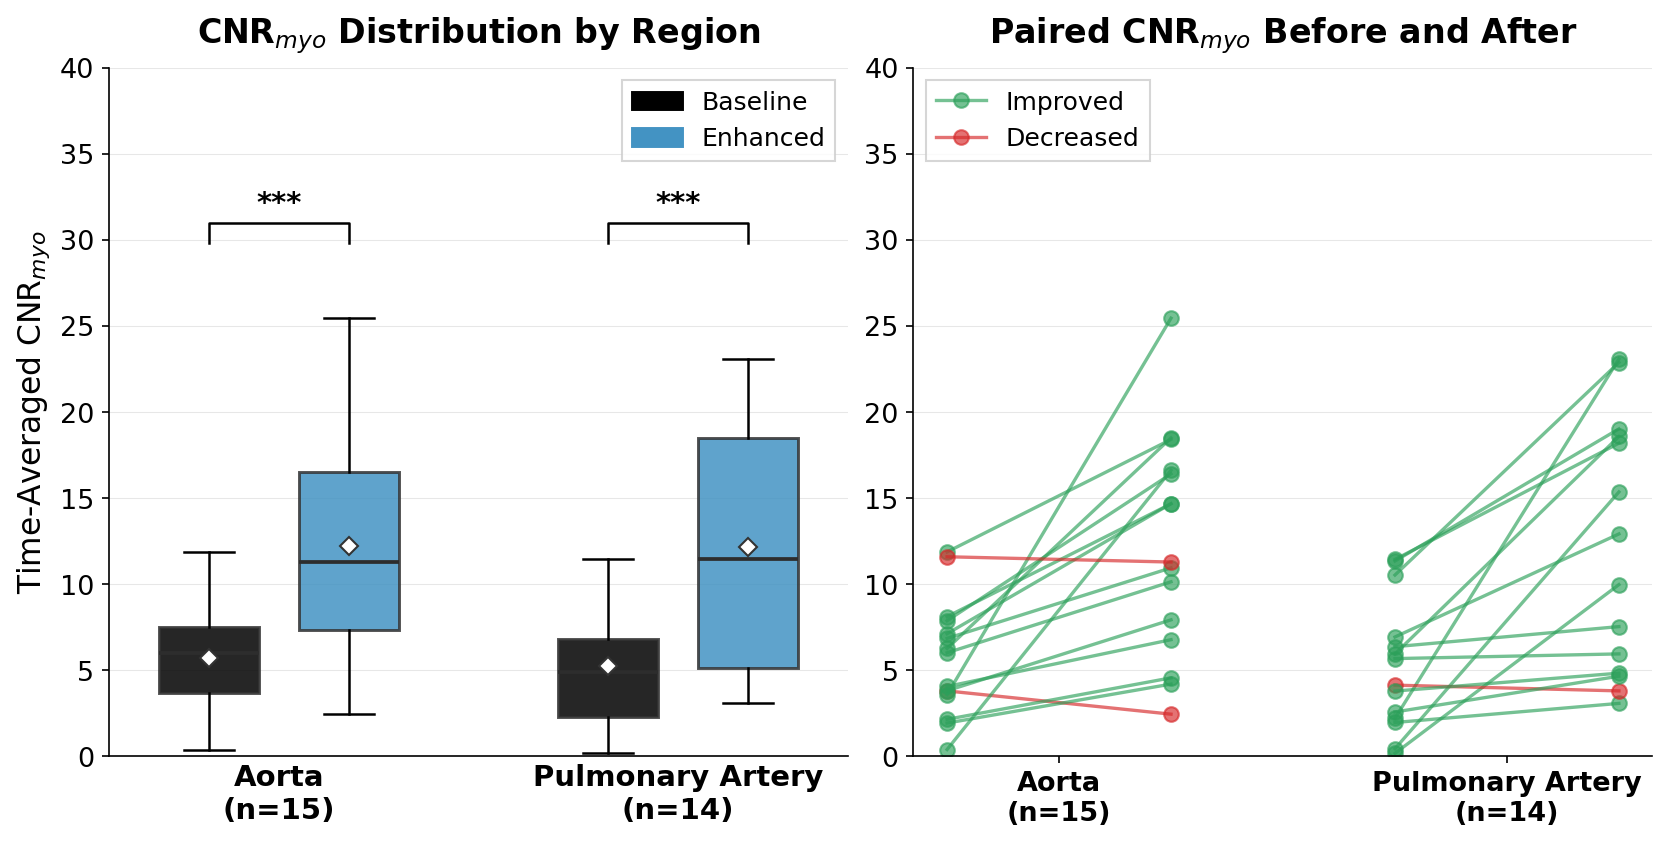

Saved: /home/ayeluru/vascular-superenhancement-4d-flow/notebooks/analysis/VSE_quantitative_analysis/figures/fig_cnr_myo_combined.png


In [18]:
# Combined 2-panel figure:
#   Left panel  = CNR_myo boxplots (Ao + PA side by side, like original Fig 1 but no SNR)
#   Right panel = Per-patient paired slopes (Ao + PA side by side)

fig, (ax_box, ax_slope) = plt.subplots(1, 2, figsize=(11, 5.5), constrained_layout=True)

# Shared y-limits
all_cnr_vals = []
for region in cnr_regions:
    cn, cv = _get_nv(cnr_myo_avg, region, "cnr_mean")
    all_cnr_vals.extend([cn, cv])
YLIM = (0, 40)

# ── Left panel: boxplots ──
box_data, box_positions, box_colors = [], [], []
region_n = {}
for i, region in enumerate(cnr_regions):
    cnr_n, cnr_v = _get_nv(cnr_myo_avg, region, "cnr_mean")
    region_n[region] = len(cnr_n)
    offset = i * 2.0
    box_data.extend([cnr_n, cnr_v])
    box_positions.extend([offset, offset + 0.7])
    box_colors.extend([COLORS["normal"], COLORS["vse"]])

bp = ax_box.boxplot(box_data, positions=box_positions, widths=0.5, **BOXPLOT_KW)
color_boxes(bp, box_colors)

tick_centers = [i * 2.0 + 0.35 for i in range(len(cnr_regions))]
ax_box.set_xticks(tick_centers)
ax_box.set_xticklabels([f"{REGION_LABELS[r]}\n(n={region_n[r]})" for r in cnr_regions],
                       fontweight="bold", fontsize=14)
ax_box.tick_params(axis="x", length=0)
ax_box.tick_params(axis="y", labelsize=13)
ax_box.set_ylim(YLIM)
ax_box.set_ylabel("Time-Averaged CNR$_{myo}$", fontsize=15)
ax_box.set_title("CNR$_{myo}$ Distribution by Region", fontweight="bold", fontsize=16, pad=12)

bracket_y = 31
bracket_h = 1.2
for i, region in enumerate(cnr_regions):
    _, sig_cnr = sig_cache[("CNR_myo", region)]
    if sig_cnr != "ns":
        x0, x1 = i * 2.0, i * 2.0 + 0.7
        ax_box.plot([x0, x0, x1, x1],
                    [bracket_y - bracket_h, bracket_y, bracket_y, bracket_y - bracket_h],
                    color="black", linewidth=1.2, clip_on=False)
        ax_box.text((x0 + x1) / 2, bracket_y + 0.3, sig_cnr,
                    ha="center", va="bottom", fontsize=14, fontweight="bold")

ax_box.legend(handles=LEGEND_HANDLES, loc="upper right", ncol=1,
              frameon=True, fancybox=False, edgecolor="#ccc", fontsize=12)

# ── Right panel: paired slopes ──
pdf = cnr_myo_pivot.reset_index()
for i, region in enumerate(cnr_regions):
    sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
    x_bl, x_en = i * 2.0, i * 2.0 + 1.0
    for _, row in sub.iterrows():
        color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
        ax_slope.plot([x_bl, x_en], [row["normal"], row["vse"]],
                      marker="o", color=color, alpha=0.65,
                      linewidth=1.6, markersize=7)

slope_tick_centers = [i * 2.0 + 0.5 for i in range(len(cnr_regions))]
ax_slope.set_xticks(slope_tick_centers)
ax_slope.set_xticklabels([f"{REGION_LABELS[r]}\n(n={region_n[r]})" for r in cnr_regions],
                         fontweight="bold", fontsize=14)
ax_slope.set_ylim(YLIM)
ax_slope.tick_params(labelsize=13)
ax_slope.set_title("Paired CNR$_{myo}$ Before and After", fontweight="bold", fontsize=16, pad=12)

slope_handles = [
    plt.Line2D([], [], color=SLOPE_UP, marker="o",
               linewidth=1.6, markersize=7, alpha=0.65, label="Improved"),
    plt.Line2D([], [], color=SLOPE_DOWN, marker="o",
               linewidth=1.6, markersize=7, alpha=0.65, label="Decreased"),
]
ax_slope.legend(handles=slope_handles, loc="upper left", ncol=1,
                frameon=True, fancybox=False, edgecolor="#ccc", fontsize=12)

out = FIG_DIR / "fig_cnr_myo_combined.png"
fig.savefig(out, bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
print(f"Saved: {out}")

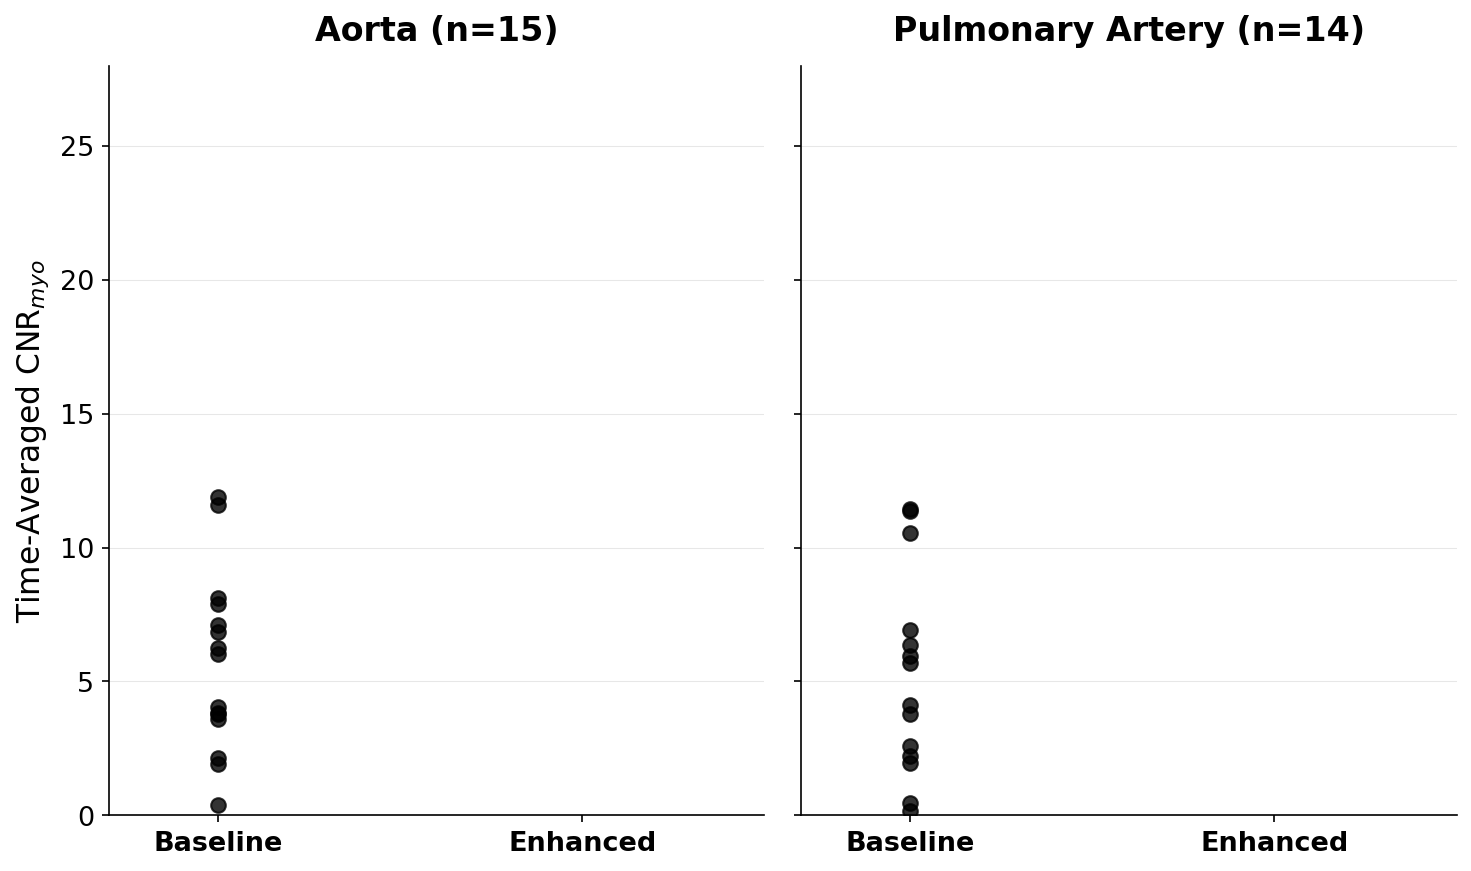

Saved: fig2_cnr_myo_paired_baseline.png


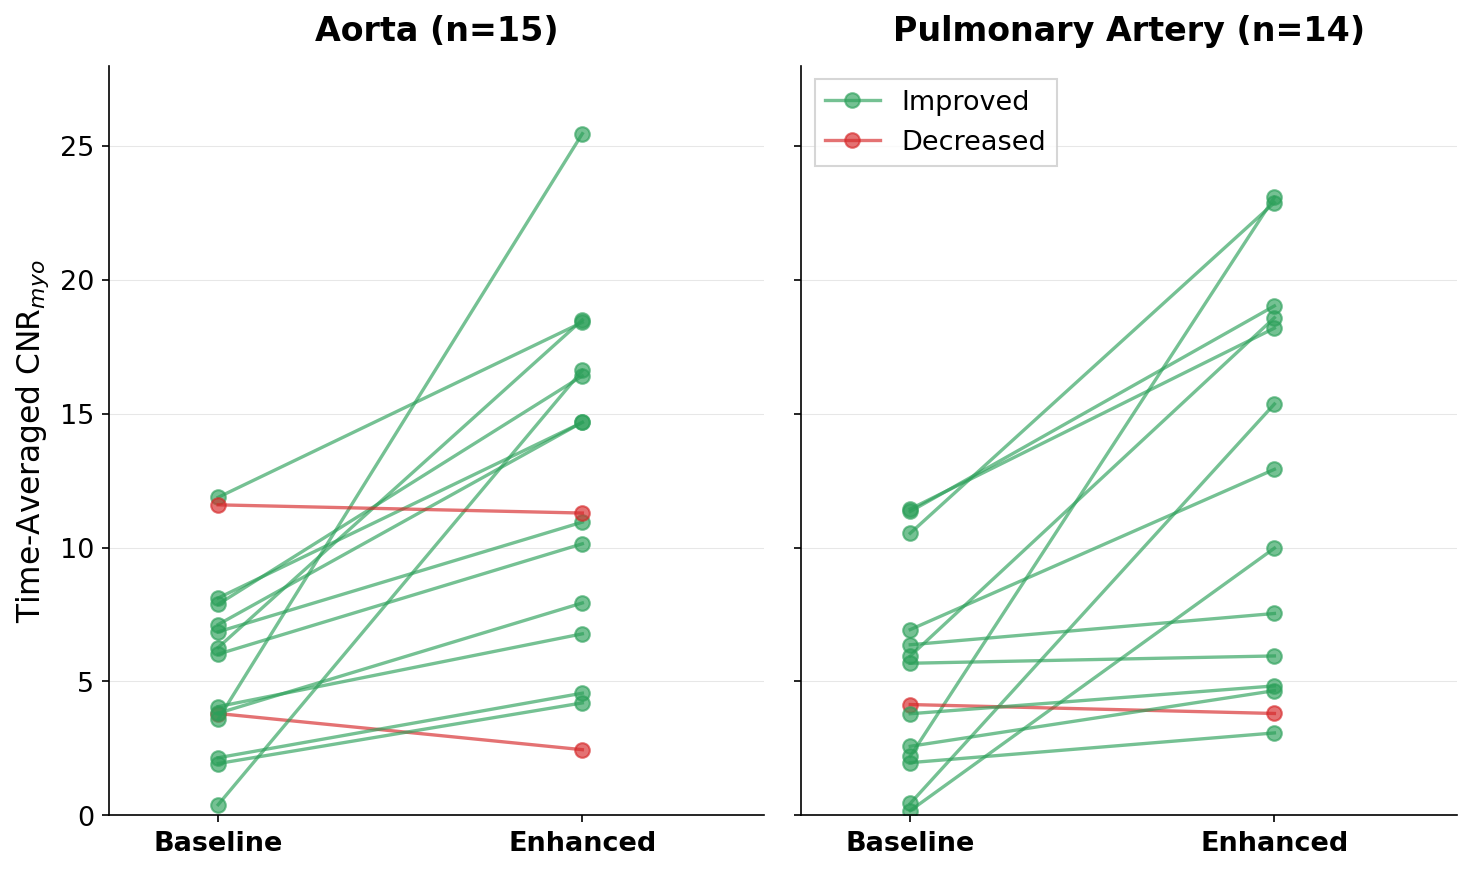

Saved: fig2_cnr_myo_paired_full.png


In [19]:
SLOPE_UP = "#2ca05a"
SLOPE_DOWN = "#d62728"

def _paired_slope(pivot_df, region_list, ylabel, fig_basename,
                  figsize_per_panel=(5, 6)):
    """Defense-ready paired slope graph with build-up stages."""

    pdf_all = pivot_df.reset_index().dropna(subset=["normal", "vse"])
    all_vals = pd.concat([pdf_all["normal"], pdf_all["vse"]])
    ylim = (min(0, all_vals.min() * 0.95), all_vals.max() * 1.10)

    STAGES = [
        ("baseline", False),
        ("full",     True),
    ]

    for stage_name, show_enhanced in STAGES:
        fig, axes = plt.subplots(
            1, len(region_list),
            figsize=(figsize_per_panel[0] * len(region_list), figsize_per_panel[1]),
            sharey=True,
        )
        if len(region_list) == 1:
            axes = [axes]

        for ax, region in zip(axes, region_list):
            pdf = pivot_df.reset_index()
            sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])

            if show_enhanced:
                for _, row in sub.iterrows():
                    color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
                    ax.plot([0, 1], [row["normal"], row["vse"]],
                            marker="o", color=color, alpha=0.65,
                            linewidth=1.6, markersize=7)
            else:
                ax.plot(np.zeros(len(sub)), sub["normal"].values,
                        "o", color="black", alpha=0.8, markersize=7)

            ax.set_xticks([0, 1])
            ax.set_xticklabels([LABELS["normal"], LABELS["vse"]],
                               fontweight="bold", fontsize=14)
            n_region = len(sub)
            ax.set_title(f"{REGION_LABELS[region]} (n={n_region})",
                         fontweight="bold", fontsize=16, pad=12)
            ax.set_xlim(-0.3, 1.5)
            ax.set_ylim(ylim)
            ax.tick_params(labelsize=13)

        axes[0].set_ylabel(ylabel, fontsize=15)

        if show_enhanced:
            legend_handles = [
                plt.Line2D([], [], color=SLOPE_UP, marker="o",
                           linewidth=1.6, markersize=7, alpha=0.65, label="Improved"),
                plt.Line2D([], [], color=SLOPE_DOWN, marker="o",
                           linewidth=1.6, markersize=7, alpha=0.65, label="Decreased"),
            ]
            axes[-1].legend(handles=legend_handles, loc="upper left", ncol=1,
                            frameon=True, fancybox=False, edgecolor="#ccc",
                            fontsize=13)

        fig.tight_layout()
        fig.savefig(FIG_DIR / f"{fig_basename}_{stage_name}.png",
                    bbox_inches="tight", dpi=300, facecolor="white")
        plt.show()
        print(f"Saved: {fig_basename}_{stage_name}.png")

_paired_slope(cnr_myo_pivot, cnr_regions,
              "Time-Averaged CNR$_{myo}$",
              "fig2_cnr_myo_paired")

## Figure 3: Per-Patient Signal Intensity — Baseline → Enhanced

Same paired slope format, now showing raw mean SI across vessel ROI regions
(Ao, IVS, PA). Verifies that VSE boosts vessel signal.

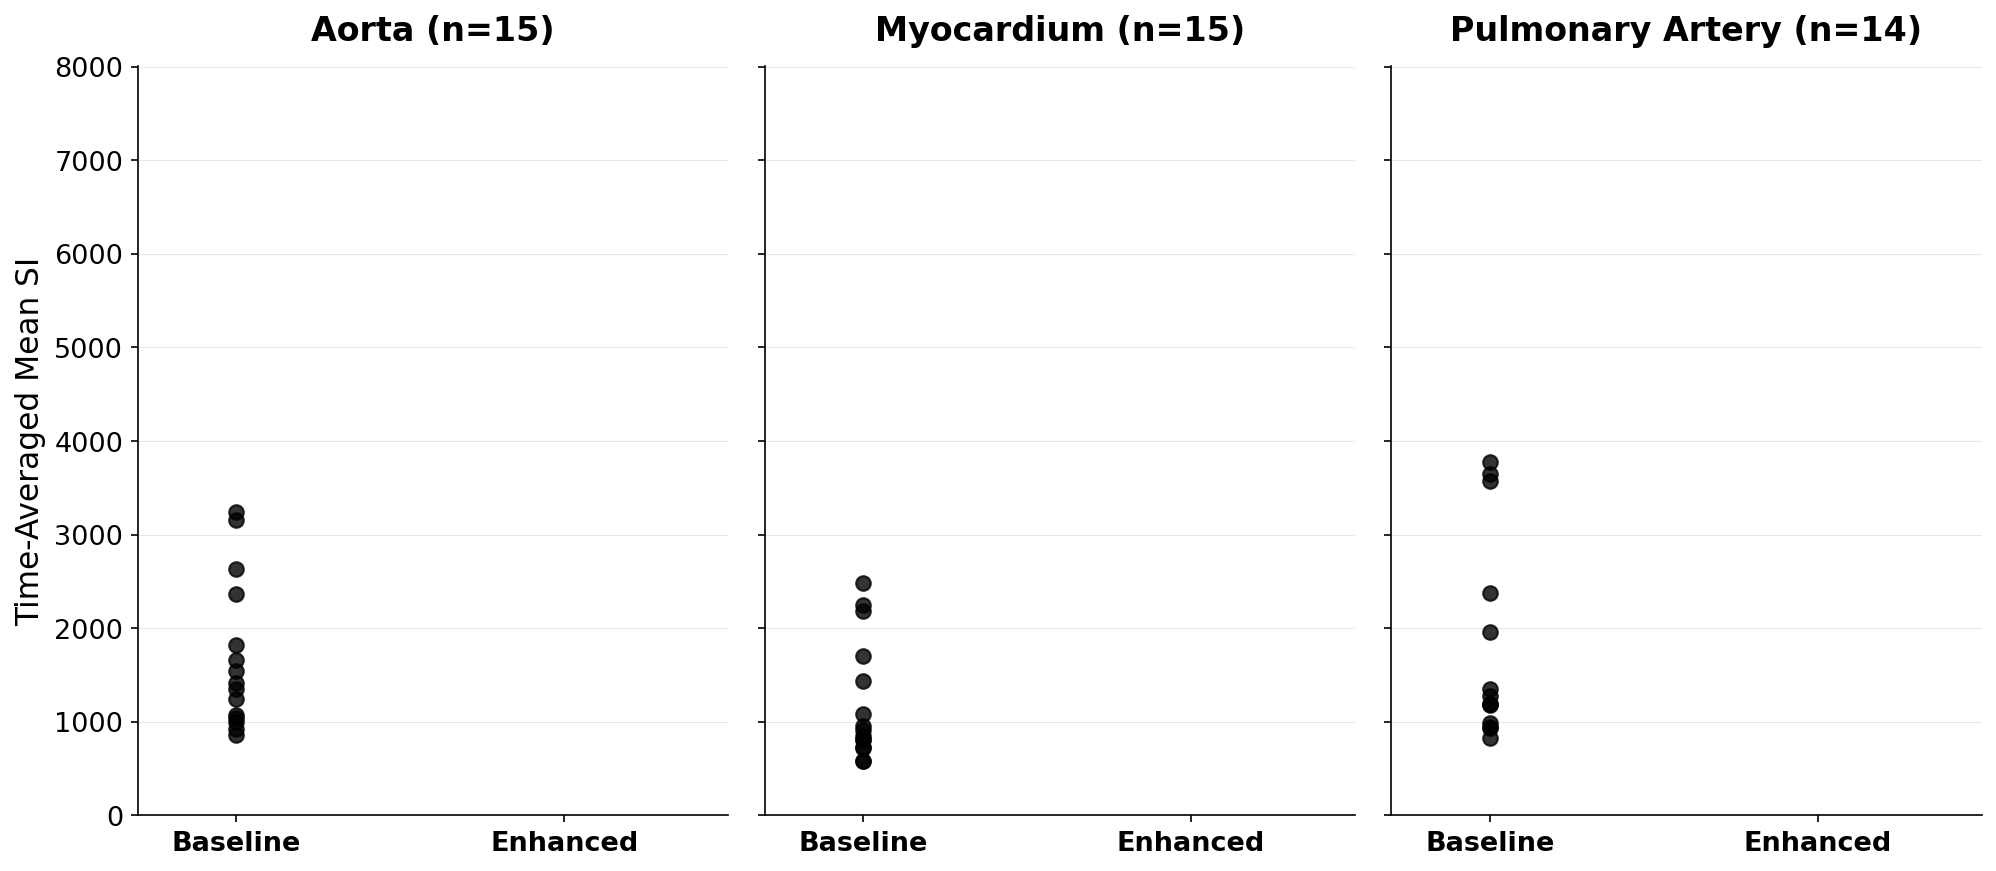

Saved: fig3_si_paired_baseline.png


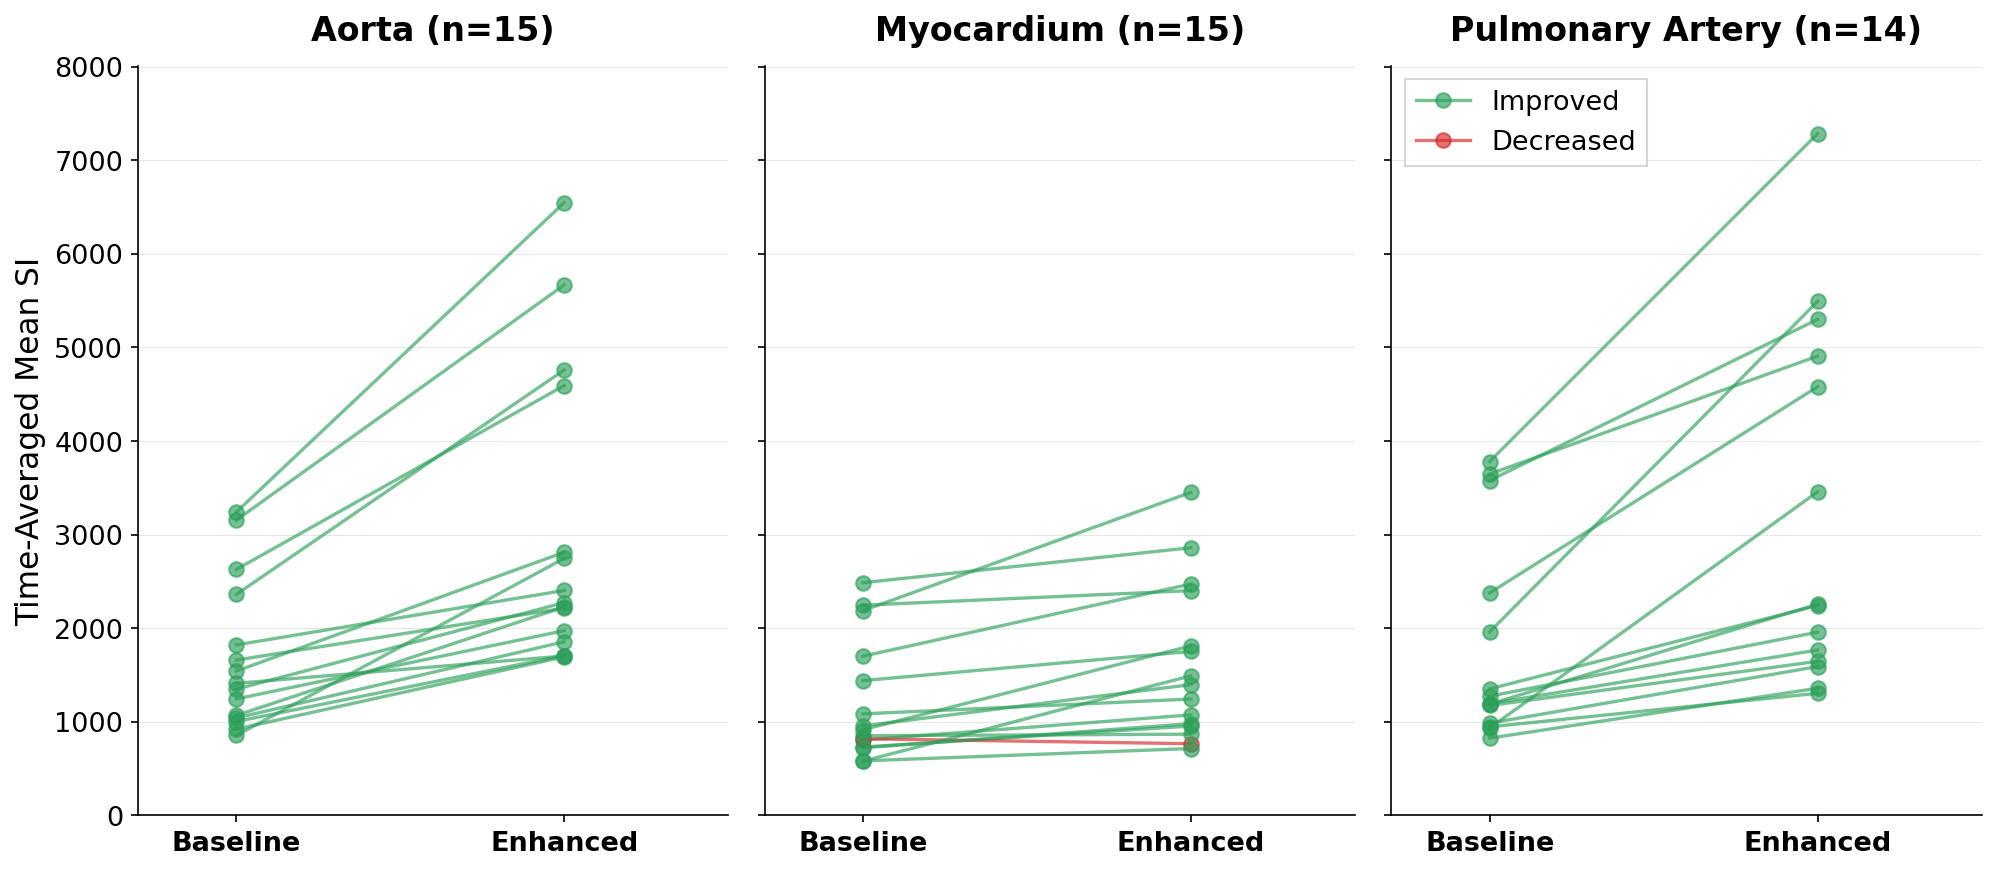

Saved: fig3_si_paired_full.png


In [ ]:
vessel_regions = [r for r in regions if r != "Air"]
_paired_slope(si_pivot, vessel_regions,
              "Time-Averaged Mean SI",
              "fig3_si_paired",
              figsize_per_panel=(4.5, 6))

## Supplemental Figure: CNR_myo Decomposition

Per-patient scatter of the change in CNR_myo numerator (signal contrast)
vs the change in CNR_myo denominator (myocardial noise) from baseline to
enhanced reconstruction. Raw units (not normalized).

/tmp/ipykernel_2686518/2375893547.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0, 1, 1])


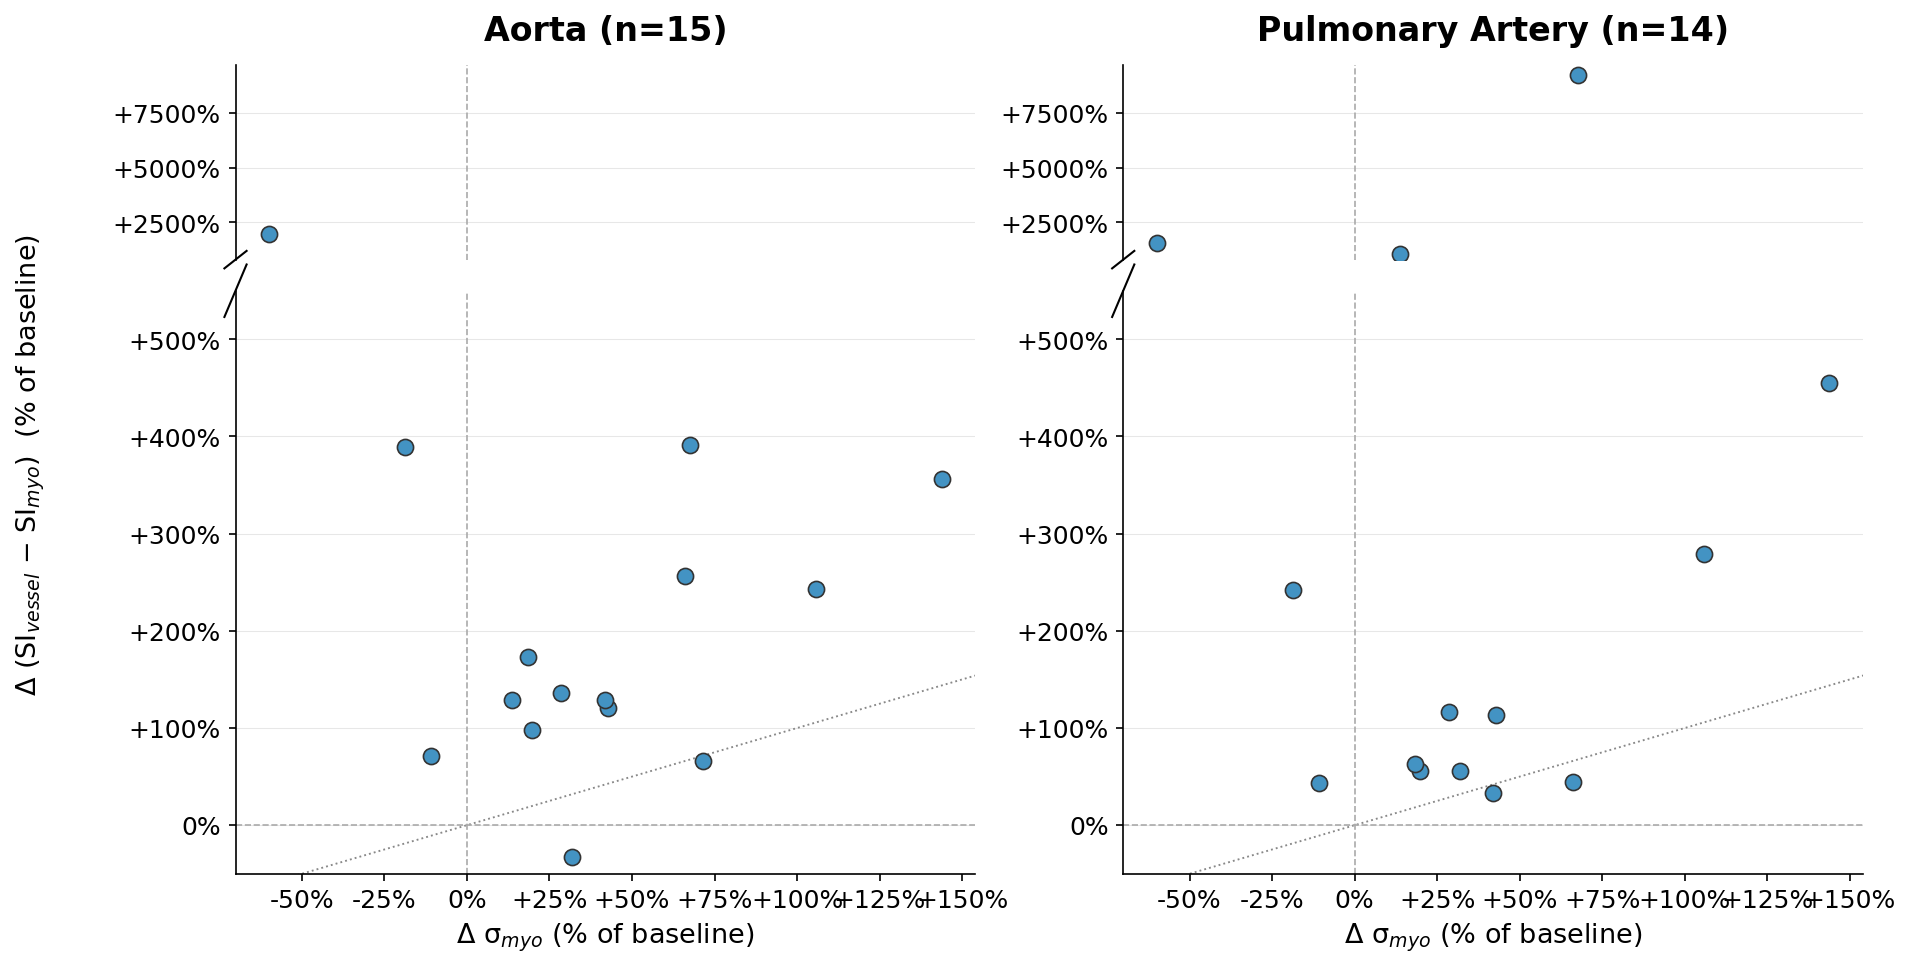

Saved: fig_supp_cnr_decomposition.png


In [ ]:
from matplotlib.ticker import FuncFormatter

decomp_norm_rows = []
for region in cnr_regions:
    for patient in sorted(data["patient"].unique()):
        vals = {}
        for recon in ["normal", "vse"]:
            vessel_sub = data[(data["patient"] == patient) & (data["region"] == region) & (data["reconstruction"] == recon)]
            ivs_sub = data[(data["patient"] == patient) & (data["region"] == "IVS") & (data["reconstruction"] == recon)]
            if vessel_sub.empty or ivs_sub.empty:
                continue
            vals[recon] = {
                "numerator": vessel_sub["mean"].mean() - ivs_sub["mean"].mean(),
                "denominator": ivs_sub["std"].mean(),
            }
        if "normal" in vals and "vse" in vals:
            num_bl, den_bl = vals["normal"]["numerator"], vals["normal"]["denominator"]
            num_en, den_en = vals["vse"]["numerator"], vals["vse"]["denominator"]
            decomp_norm_rows.append({
                "patient": patient, "region": region,
                "frac_num": (num_en - num_bl) / abs(num_bl) if num_bl != 0 else np.nan,
                "frac_den": (den_en - den_bl) / abs(den_bl) if den_bl != 0 else np.nan,
            })

decomp_norm = pd.DataFrame(decomp_norm_rows).dropna()

Y_BREAK_LO = 5.5
Y_BREAK_HI = 8
HEIGHT_RATIO = [1, 3]

pct_fmt = FuncFormatter(lambda x, _: f"{x:+.0%}" if x != 0 else "0%")

x_ptp = np.ptp(decomp_norm["frac_den"].values)
x_pad = 0.05 * x_ptp if x_ptp > 0 else 0.1
x_lim_shared = (decomp_norm["frac_den"].min() - x_pad, decomp_norm["frac_den"].max() + x_pad)
y_top_max = decomp_norm["frac_num"].max() * 1.05

fig, all_axes = plt.subplots(2, len(cnr_regions),
                              figsize=(7 * len(cnr_regions), 7),
                              sharex="col",
                              gridspec_kw={"height_ratios": HEIGHT_RATIO, "hspace": 0.08})

for col, region in enumerate(cnr_regions):
    ax_top = all_axes[0, col]
    ax_bot = all_axes[1, col]
    sub = decomp_norm[decomp_norm["region"] == region]
    n_region = len(sub)

    sub_bot = sub[sub["frac_num"] <= Y_BREAK_LO]
    sub_top = sub[sub["frac_num"] >= Y_BREAK_HI]

    ax_bot.scatter(sub_bot["frac_den"], sub_bot["frac_num"], s=60, color=COLORS["vse"],
                   edgecolors="#333", linewidth=0.8, zorder=3)
    ax_top.scatter(sub_top["frac_den"], sub_top["frac_num"], s=60, color=COLORS["vse"],
                   edgecolors="#333", linewidth=0.8, zorder=3)

    id_lo = min(x_lim_shared[0], -0.5)
    id_hi = max(x_lim_shared[1], y_top_max)
    for ax in (ax_top, ax_bot):
        ax.plot([id_lo, id_hi], [id_lo, id_hi], color="#888", linewidth=0.9,
                linestyle=":", zorder=2)
        ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax.xaxis.set_major_formatter(pct_fmt)
        ax.yaxis.set_major_formatter(pct_fmt)
        ax.tick_params(labelsize=12)

    ax_bot.set_ylim(-0.5, Y_BREAK_LO)
    ax_top.set_ylim(Y_BREAK_HI, y_top_max)
    for ax in (ax_top, ax_bot):
        ax.set_xlim(x_lim_shared)

    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(bottom=False, labelbottom=False)

    d = 0.015
    bkw = dict(color="black", clip_on=False, linewidth=1, zorder=10)
    ax_top.plot([-d, +d], [-d*3, +d*3], transform=ax_top.transAxes, **bkw)
    ax_bot.plot([-d, +d], [1 - d*3, 1 + d*3], transform=ax_bot.transAxes, **bkw)

    ax_bot.set_xlabel("Δ σ$_{myo}$ (% of baseline)", fontsize=13)
    ax_top.set_title(f"{REGION_LABELS[region]} (n={n_region})",
                     fontweight="bold", fontsize=16, pad=12)

fig.text(0.02, 0.5, "Δ (SI$_{vessel}$ − SI$_{myo}$)  (% of baseline)",
         va="center", rotation="vertical", fontsize=13)

fig.tight_layout(rect=[0.04, 0, 1, 1])
fig.savefig(FIG_DIR / "fig_supp_cnr_decomposition.png",
            bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
print("Saved: fig_supp_cnr_decomposition.png")

## ~~Supplemental Figure: Time Curves~~ (dropped)

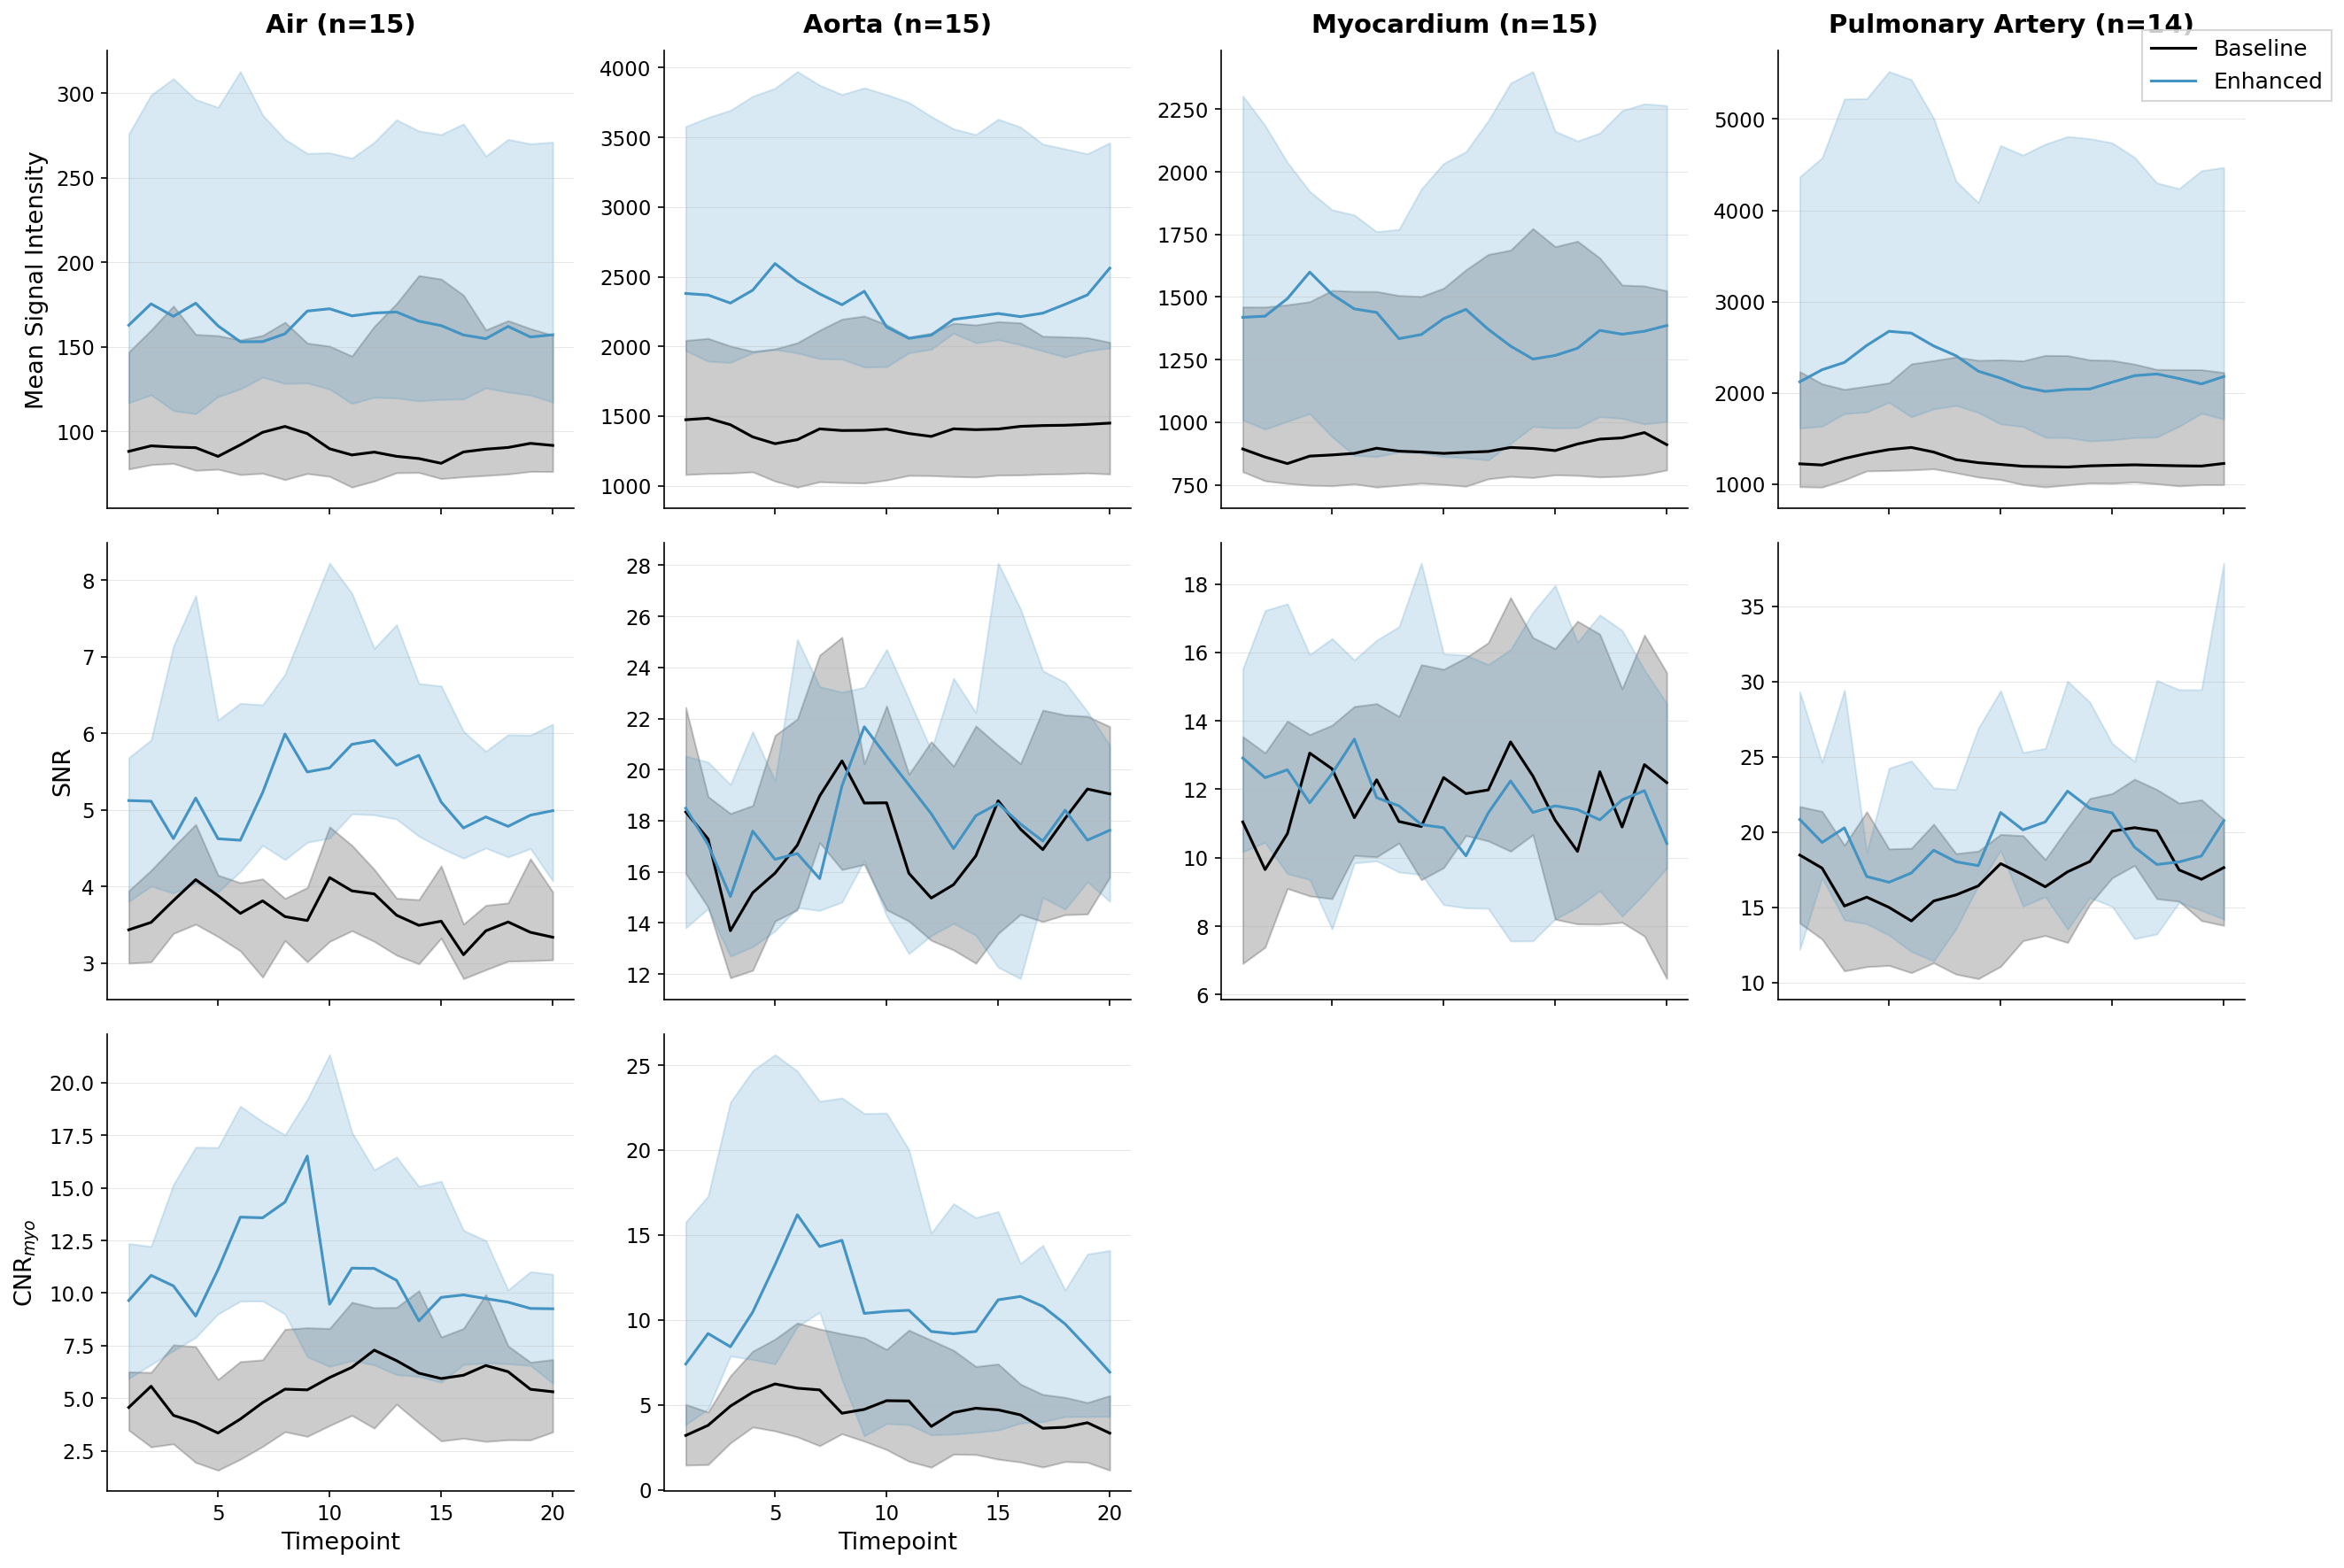

Saved: fig_supp_time_curves.png


In [ ]:
# Dropped — time curves figure deferred until more patients available